# GMM vs K-Means: Soft Clustering with Gaussian Mixture Models

This notebook is a small machine learning experiment comparing **K-Means** and **Gaussian Mixture Models (GMM)**.

The goal is to understand the difference between:

- **Hard clustering**: each point belongs to exactly one cluster
- **Soft clustering**: each point has probabilities of belonging to different clusters

I use a small synthetic 2D dataset so the behaviour of the models is easy to visualise.

## 1. Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

## 2. Generate a synthetic 2D dataset

We create 3 clusters with different standard deviations.  
Then we apply a linear transformation to make the clusters more elliptical.

This makes the comparison more interesting because:

- K-Means usually works best with roughly circular clusters
- GMM can model elliptical Gaussian-shaped clusters

In [2]:
X, y_true = make_blobs(
    n_samples=500,
    centers=3,
    cluster_std=[1.0, 1.8, 0.8],
    random_state=42
)

# Transform the data so the clusters become more elliptical
transformation = np.array([
    [0.6, -0.6],
    [-0.4, 0.8]
])

X = X @ transformation

df = pd.DataFrame(X, columns=["x1", "x2"])
df.head()

,x1,x2
0,-0.599065,-2.377995
1,-0.878886,1.629061
2,4.941621,-4.734328
3,-4.761092,7.781400
4,3.585785,-3.090331


## 3. Visualise the dataset

In a real unsupervised learning problem, we usually do not know the true labels.  
Here, we only visualise the points without labels.

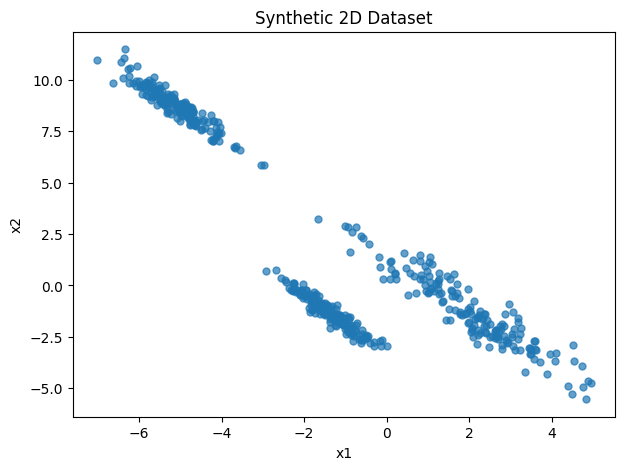

In [3]:
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], s=25, alpha=0.7)
plt.title("Synthetic 2D Dataset")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

## 4. Fit K-Means

K-Means assigns every point to exactly one cluster.

This is called hard clustering.

In [4]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X)

df["kmeans_cluster"] = kmeans_labels
df.head()

,x1,x2,kmeans_cluster
0,-0.599065,-2.377995,0
1,-0.878886,1.629061,0
2,4.941621,-4.734328,2
3,-4.761092,7.781400,1
4,3.585785,-3.090331,2


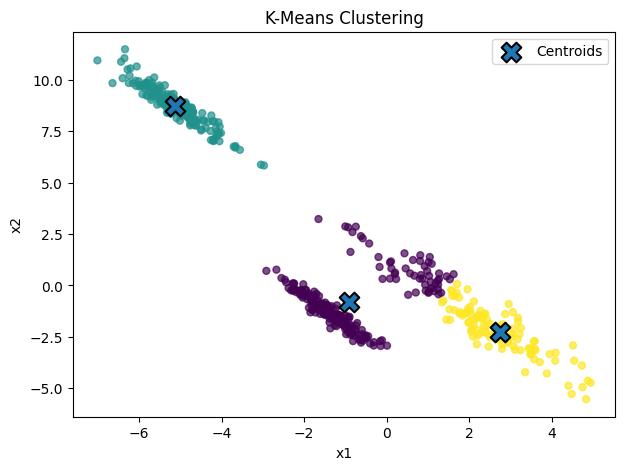

In [5]:
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=kmeans_labels, s=25, alpha=0.7)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=200,
    edgecolor="black",
    linewidth=1.5,
    label="Centroids"
)
plt.title("K-Means Clustering")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()

## 5. Fit Gaussian Mixture Model

A Gaussian Mixture Model assumes that the data was generated from several Gaussian distributions.

Instead of only assigning each point to one cluster, GMM can estimate the probability that a point belongs to each Gaussian component.

This is called soft clustering.

In [6]:
gmm = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=42
)

gmm_labels = gmm.fit_predict(X)
gmm_probs = gmm.predict_proba(X)

df["gmm_cluster"] = gmm_labels
df["gmm_max_probability"] = gmm_probs.max(axis=1)

df.head()

,x1,x2,kmeans_cluster,gmm_cluster,gmm_max_probability
0,-0.599065,-2.377995,0,0,1.000000
1,-0.878886,1.629061,0,2,1.000000
2,4.941621,-4.734328,2,2,1.000000
3,-4.761092,7.781400,1,1,0.999998
4,3.585785,-3.090331,2,2,1.000000


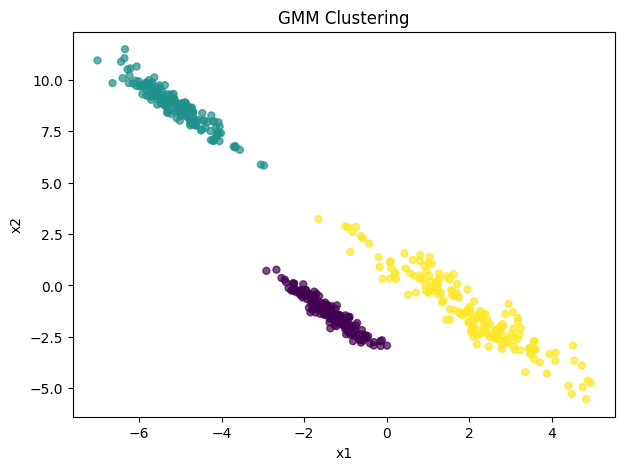

In [7]:
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=gmm_labels, s=25, alpha=0.7)
plt.title("GMM Clustering")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

## 6. Compare K-Means and GMM assignments

Both models return cluster labels, but they are based on different ideas.

K-Means:

- uses distances to centroids
- prefers round/spherical clusters
- gives hard labels only

GMM:

- fits Gaussian distributions
- can model elliptical clusters
- gives both labels and probabilities

In [8]:
comparison = df[["x1", "x2", "kmeans_cluster", "gmm_cluster", "gmm_max_probability"]]
comparison.head(10)

,x1,x2,kmeans_cluster,gmm_cluster,gmm_max_probability
0,-0.599065,-2.377995,0,0,1.000000
1,-0.878886,1.629061,0,2,1.000000
2,4.941621,-4.734328,2,2,1.000000
3,-4.761092,7.781400,1,1,0.999998
4,3.585785,-3.090331,2,2,1.000000
5,3.507802,-3.334915,2,2,1.000000
6,-0.116153,-2.666630,0,0,1.000000
7,2.322924,-1.569828,2,2,1.000000
8,0.944143,-0.257388,0,2,1.000000
9,-1.683995,-1.059700,0,0,1.000000


In [9]:
kmeans_silhouette = silhouette_score(X, kmeans_labels)
gmm_silhouette = silhouette_score(X, gmm_labels)

print(f"K-Means silhouette score: {kmeans_silhouette:.3f}")
print(f"GMM silhouette score: {gmm_silhouette:.3f}")

K-Means silhouette score: 0.652
GMM silhouette score: 0.636


The silhouette score is only a rough comparison here.

A higher score means the clusters are more separated according to the assigned labels.  
However, it does not fully capture the advantage of GMM, because GMM's main benefit is the probability information.

## 7. Inspect GMM probability outputs

For each point, GMM gives a probability distribution across the 3 components.

For example, one point might have probabilities like:

```text
Component 0: 0.02
Component 1: 0.91
Component 2: 0.07
```

This means the model is most confident that the point belongs to component 1.

In [10]:
prob_df = pd.DataFrame(
    gmm_probs,
    columns=["prob_component_0", "prob_component_1", "prob_component_2"]
)

prob_df["predicted_component"] = gmm_labels
prob_df["max_probability"] = gmm_probs.max(axis=1)

prob_df.head(10)

,prob_component_0,prob_component_1,prob_component_2,predicted_component,max_probability
0,1.000000e+00,1.522082e-65,1.302252e-13,0,1.000000
1,3.469794e-47,1.213289e-11,1.000000e+00,2,1.000000
2,2.699168e-130,1.134377e-44,1.000000e+00,2,1.000000
3,4.433393e-79,9.999982e-01,1.767208e-06,1,0.999998
4,1.328365e-111,3.782736e-34,1.000000e+00,2,1.000000
5,1.709789e-98,2.792007e-34,1.000000e+00,2,1.000000
6,1.000000e+00,6.213999e-59,2.322843e-10,0,1.000000
7,4.725362e-96,1.574864e-25,1.000000e+00,2,1.000000
8,2.869012e-70,1.639440e-18,1.000000e+00,2,1.000000
9,1.000000e+00,1.577898e-64,4.822759e-15,0,1.000000


## 8. Find uncertain points

A point is uncertain if its highest membership probability is not very high.

For example:

- max probability = 0.99 means very confident
- max probability = 0.55 means uncertain

These uncertain points usually appear near overlapping regions between clusters.

In [11]:
uncertain_threshold = 0.75

uncertain_points = df[df["gmm_max_probability"] < uncertain_threshold]

print(f"Number of uncertain points: {len(uncertain_points)}")
print(f"Percentage uncertain: {len(uncertain_points) / len(df) * 100:.2f}%")

uncertain_points.head()

Number of uncertain points: 0
Percentage uncertain: 0.00%


,x1,x2,kmeans_cluster,gmm_cluster,gmm_max_probability


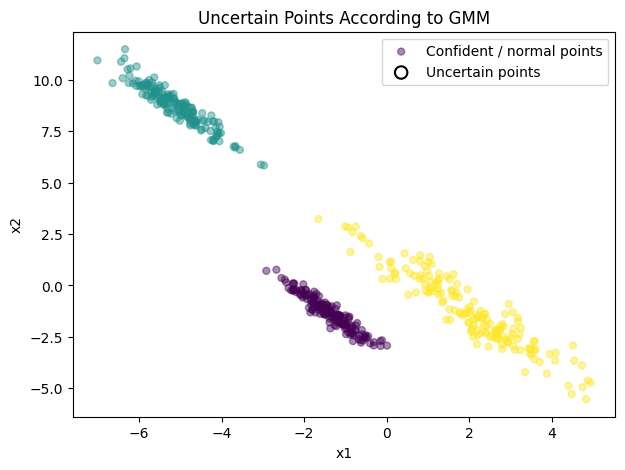

In [12]:
plt.figure(figsize=(7, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=gmm_labels,
    s=25,
    alpha=0.45,
    label="Confident / normal points"
)

plt.scatter(
    uncertain_points["x1"],
    uncertain_points["x2"],
    s=80,
    facecolors="none",
    edgecolors="black",
    linewidth=1.5,
    label="Uncertain points"
)

plt.title("Uncertain Points According to GMM")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()

## 9. Visualise confidence level

Instead of colouring by cluster, we colour points by their maximum GMM probability.

Darker/lighter regions show how confident the model is about the assignment.

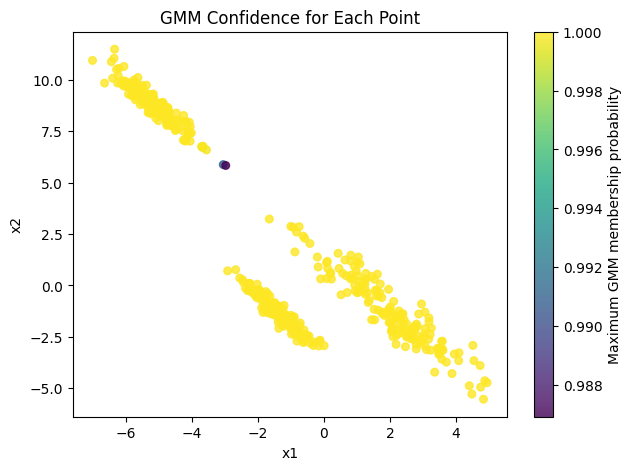

In [13]:
plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    X[:, 0],
    X[:, 1],
    c=df["gmm_max_probability"],
    s=30,
    alpha=0.8
)

plt.colorbar(scatter, label="Maximum GMM membership probability")
plt.title("GMM Confidence for Each Point")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

## 10. Check a few uncertain examples

These are points where GMM is less confident.

In [14]:
uncertain_indices = uncertain_points.index[:10]

example_probs = prob_df.loc[uncertain_indices].copy()
example_probs.insert(0, "x1", df.loc[uncertain_indices, "x1"])
example_probs.insert(1, "x2", df.loc[uncertain_indices, "x2"])

example_probs

,x1,x2,prob_component_0,prob_component_1,prob_component_2,predicted_component,max_probability


## 11. Key takeaways

In this notebook:

- K-Means gives a single cluster label for each point
- GMM gives both a cluster label and membership probabilities
- K-Means works well when clusters are roughly circular
- GMM is more flexible because it can model elliptical Gaussian components
- GMM is useful when we care about uncertainty, not just final cluster labels

The most important idea:

> K-Means asks: "Which centroid is closest?"  
> GMM asks: "How likely is this point under each Gaussian component?"

## Optional next experiments

You can extend this notebook by trying:

1. Change `cluster_std`
2. Change `n_components`
3. Compare `covariance_type="full"` with `"diag"` or `"spherical"`
4. Plot GMM decision boundaries
5. Use GMM for anomaly detection by checking low likelihood points